# Techno-Quantamental Analyzer: Report Analysis & Analytics
This notebook scans through all directories in `data/reports/runs/` and compiles stock analyzer outputs according to their `run_config.json`. It collects, aggregates, and analyzes:
1. **Stock frequency & prompt mode cross-tabulations** (e.g., how often they show up in `can_slim_growth`, `master_analyst`, `institutional_accumulation`)
2. **Confidence score stability** over varying run dates
3. **Chronological arrivals of new tickers** (e.g., finding new tickers emerging on recent dates like May 25, May 26)

Additionally, it provides beautiful static **Seaborn** heatmaps and interactive **Plotly** trend visualizations.

In [2]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from rich import print as rprint
from rich.pretty import pprint

# Set plot styles
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.family"] = "sans-serif"

BASE_RUNS_DIR = os.path.join("..", "data", "reports", "runs")
if not os.path.exists(BASE_RUNS_DIR):
    # Fallback if executing from workspace root
    BASE_RUNS_DIR = os.path.join("data", "reports", "runs")

rprint(f"[bold green]✓[/bold green] Setup completed. Root runs directory: [cyan]{BASE_RUNS_DIR}[/cyan]")

✓ Setup completed. Root runs directory: ../data/reports/runs

## Step 1: Ingestion & Parser of Runs
We scan all runs subdirectories in `data/reports/runs/` and for each folder, we:
- Load and check `run_config.json`. If missing, we skip the directory as instructed.
- Parse prompt mode, model, and timestamp from the run configuration.
- Locate all JSON files representing individual stock reports (skipping `run_config.json`).
- Load each stock report and extract core parameters: `ticker`, `confidence_score`, `suggested_entry_pivot`, and `suggested_stop_loss` along with run metadata.

In [3]:
def load_all_run_reports(runs_dir):
    all_records = []
    run_configs_loaded = {}
    
    if not os.path.exists(runs_dir):
        rprint(f"[bold red]Error:[/bold red] Runs directory '{runs_dir}' does not exist.")
        return pd.DataFrame(), {}
        
    subdirs = sorted(os.listdir(runs_dir))
    rprint(f"Found [bold blue]{len(subdirs)}[/bold blue] potential run directories in '{runs_dir}'. Scanning...")
    
    skipped_dirs_count = 0
    
    for subdir in subdirs:
        subdir_path = os.path.join(runs_dir, subdir)
        if not os.path.isdir(subdir_path):
            continue
            
        # Look for run_config.json
        config_path = os.path.join(subdir_path, "run_config.json")
        if not os.path.exists(config_path):
            skipped_dirs_count += 1
            continue
            
        # Load run config
        try:
            with open(config_path, "r", encoding="utf-8") as f:
                config_data = json.load(f)
        except Exception as e:
            rprint(f"[yellow]Warning:[/yellow] Could not parse run_config.json in '{subdir}': {e}. Skipping.")
            continue
            
        prompt_mode = config_data.get("prompt_mode", "unknown")
        model = config_data.get("model", "unknown")
        timestamp_str = config_data.get("timestamp", "")
        
        # Clean up timestamp and derive date
        # If timestamp is missing, try parsing subdir name (e.g. 20260526_171547 -> 2026-05-26)
        if timestamp_str:
            try:
                run_date = timestamp_str.split("T")[0]
            except Exception:
                run_date = "unknown"
        else:
            # fallback to folder name pattern
            if len(subdir) >= 8 and subdir[:8].isdigit():
                run_date = f"{subdir[:4]}-{subdir[4:6]}-{subdir[6:8]}"
            else:
                run_date = subdir
                
        run_configs_loaded[subdir] = {
            "run_id": subdir,
            "prompt_mode": prompt_mode,
            "model": model,
            "timestamp": timestamp_str,
            "run_date": run_date,
            "total_watchlist_count": config_data.get("funnel_stats", {}).get("final_watchlist_count", None)
        }
        
        # Read all stock JSONs in this directory
        stock_files = glob.glob(os.path.join(subdir_path, "*.json"))
        for fpath in stock_files:
            fname = os.path.basename(fpath)
            if fname == "run_config.json":
                continue
                
            try:
                with open(fpath, "r", encoding="utf-8") as sf:
                    report = json.load(sf)
            except Exception as e:
                # If single report is corrupt, log and continue
                continue
                
            # Extract core fields according to BaseAnalysisOutput
            ticker = report.get("ticker", "").upper()
            if not ticker:
                # Try parsing ticker from filename like 001210.SZ_2026-05-14.json
                ticker = fname.split("_")[0].upper().replace(".JSON", "")
                
            confidence_score = report.get("confidence_score", None)
            suggested_entry_pivot = report.get("suggested_entry_pivot", None)
            suggested_stop_loss = report.get("suggested_stop_loss", None)
            is_breakout_safe = report.get("is_breakout_safe", None)
            
            all_records.append({
                "ticker": ticker,
                "confidence_score": confidence_score,
                "suggested_entry_pivot": suggested_entry_pivot,
                "suggested_stop_loss": suggested_stop_loss,
                "is_breakout_safe": is_breakout_safe,
                "run_id": subdir,
                "run_date": run_date,
                "prompt_mode": prompt_mode,
                "model": model,
                "file_path": fpath
            })
            
    df_all_reports = pd.DataFrame(all_records)
    
    # Print Ingestion Stats
    rprint(f"[bold green]✓[/bold green] Ingestion completed.")
    rprint(f"  - Total directories skipped (missing run_config.json): [bold yellow]{skipped_dirs_count}[/bold yellow]")
    rprint(f"  - Total valid run configurations loaded: [bold green]{len(run_configs_loaded)}[/bold green]")
    rprint(f"  - Total stock reports parsed: [bold green]{len(df_all_reports)}[/bold green]")
    
    return df_all_reports, run_configs_loaded

df_all_reports, run_configs = load_all_run_reports(BASE_RUNS_DIR)

Found 186 potential run directories in '../data/reports/runs'. Scanning...

Warning: Could not parse run_config.json in '20260526_170551': Extra data: line 32 column 2 (char 822). Skipping.

Warning: Could not parse run_config.json in '20260527_171518': Extra data: line 30 column 2 (char 774). Skipping.

Warning: Could not parse run_config.json in '20260531_170002': Extra data: line 32 column 2 (char 820). Skipping.

Warning: Could not parse run_config.json in '20260602_171329': Extra data: line 30 column 2 (char 787). Skipping.

✓ Ingestion completed.

- Total directories skipped (missing run_config.json): 0

- Total valid run configurations loaded: 182

- Total stock reports parsed: 11373

## Step 2: Exploratory Data Analysis & Rich Previews
We inspect our compiled dataset, show raw statistics, and demonstrate example run configurations and stock analyses using the `Rich` library's pretty printing capabilities.

In [4]:
# Display standard shape & columns info
rprint(f"[bold cyan]DataFrame Shape:[/bold cyan] {df_all_reports.shape}")
rprint("[bold cyan]DataFrame Columns:[/bold cyan]")
pprint(list(df_all_reports.columns))

# Display some quick counts of null values across parsed columns
rprint("[bold yellow]Missing values counts per column:[/bold yellow]")
rprint(dict(df_all_reports.isnull().sum()))

DataFrame Shape: (11373, 10)

DataFrame Columns:

[
│   'ticker',
│   'confidence_score',
│   'suggested_entry_pivot',
│   'suggested_stop_loss',
│   'is_breakout_safe',
│   'run_id',
│   'run_date',
│   'prompt_mode',
│   'model',
│   'file_path'
]

Missing values counts per column:

{
    'ticker': np.int64(0),
    'confidence_score': np.int64(0),
    'suggested_entry_pivot': np.int64(14),
    'suggested_stop_loss': np.int64(14),
    'is_breakout_safe': np.int64(7824),
    'run_id': np.int64(0),
    'run_date': np.int64(0),
    'prompt_mode': np.int64(0),
    'model': np.int64(0),
    'file_path': np.int64(0)
}

In [5]:
df_all_reports['run_date'].sort_values()

0        2026-05-13
1        2026-05-13
2        2026-05-13
3        2026-05-13
4        2026-05-13
            ...    
11368    2026-06-11
11369    2026-06-11
11370    2026-06-11
11371    2026-06-11
11372    2026-06-11
Name: run_date, Length: 11373, dtype: str

In [6]:
# Show an example run_config.json using rich
example_run_id = list(run_configs.keys())[-1]
example_run_dir = os.path.join(BASE_RUNS_DIR, example_run_id)
example_config_path = os.path.join(example_run_dir, "run_config.json")

rprint(f"[bold magenta]Example run_config.json from directory {example_run_id}:[/bold magenta]")
with open(example_config_path, "r", encoding="utf-8") as f:
    pprint(json.load(f))

# Show an example stock report json using rich
example_stock_reports = [f for f in os.listdir(example_run_dir) if f.endswith(".json") and f != "run_config.json"]
if example_stock_reports:
    example_stock_path = os.path.join(example_run_dir, example_stock_reports[0])
    rprint(f"\n[bold magenta]Example stock report json ({example_stock_reports[0]}):[/bold magenta]")
    with open(example_stock_path, "r", encoding="utf-8") as f:
        pprint(json.load(f))
else:
    rprint("\n[yellow]No stock report files found in the latest run directory.[/yellow]")

Example run_config.json from directory 20260611_181153:

{
│   'universe_limit': 50000,
│   'min_eps_growth': 10.0,
│   'min_rev_growth': 10.0,
│   'max_rev_growth': None,
│   'min_prev_eps': None,
│   'max_prev_eps': None,
│   'min_latest_eps': None,
│   'min_market_cap': 500000000,
│   'max_market_cap': 50000000000,
│   'news_summary_max_chars': 500,
│   'max_recent_articles': 10,
│   'save_prompts': False,
│   'model': 'google/gemini-3-flash-preview',
│   'prompt_mode': 'can_slim_growth',
│   'technical_filters': [
│   │   'price > sma_50',
│   │   'price > sma_100',
│   │   'sma_50 > sma_100',
│   │   'price >= 1.20 * low_52w',
│   │   'price >= 0.80 * high_52w'
│   ],
│   'timestamp': '2026-06-11T18:13:25.148192',
│   'funnel_stats': {
│   │   'universe_count': 4687,
│   │   'fundamental_passed_count': 758,
│   │   'technical_passed_count': 91,
│   │   'final_watchlist_count': 91
│   }
}

Example stock report json (688378.SS_2026-06-11.json):

{
│   'ticker': '688378.SS',
│   'suggested_entry_pivot': 55.6,
│   'suggested_stop_loss': 50.85,
│   'confidence_score': 6,
│   'c_current_earnings': 'Exceptional. EPS growth of 220% and revenue growth of 53.55% Y/Y satisfy the highest CAN SLIM requirements.',
│   'a_annual_earnings': "Strong. Historical rating of 'B' with high gross margins (54%) indicates a profitable and expanding business model.",
│   'n_new_catalyst': 'New 52-week highs reached recently; however, current price is extended from the original base. The OLED tech cycle acts as the macro driver.',
│   's_supply_demand': 'Mixed. While the float is manageable, recent daily bars show heavy selling volume (red bars) exceeding average, indicating distribution at the highs.',
│   'l_leader_laggard': 'True leader. 1Y price performance of 186% dramatically outperforms the broader market and shows extreme relative strength.',
│   'i_institutional_sponsorship': 'Likely high given the liquidity and sector importance, though bulk rating suggests room for further quality institutional accumulation.',
│   'm_market_direction': 'Corrective/Volatile. Stock has sliced below its SMA20 on high volume, indicating a short-term trend break despite the long-term uptrend.',
│   'is_breakout_safe': False
}

## Step 3: Stock Frequencies & Prompt Mode Analysis
We count how often each stock ticker is processed across different prompt configurations (`prompt_mode`). This gives us clear visibility on which tickers appear frequently and under which methodologies.

In [7]:
# Distribution of prompt modes
rprint("[bold cyan]Reports per Prompt Mode:[/bold cyan]")
prompt_counts = df_all_reports["prompt_mode"].value_counts()
for mode, count in prompt_counts.items():
    rprint(f"  - [bold]{mode}[/bold]: {count} reports")

# Cross-tabulate tickers vs. prompt modes
ticker_by_mode = pd.crosstab(df_all_reports["ticker"], df_all_reports["prompt_mode"])
ticker_by_mode["total_appearances"] = ticker_by_mode.sum(axis=1)
ticker_by_mode_sorted = ticker_by_mode.sort_values(by="total_appearances", ascending=False)

rprint("\n[bold cyan]Top 20 most frequently appearing stock tickers across all prompt modes:[/bold cyan]")
display(ticker_by_mode_sorted.head(20))

Reports per Prompt Mode:

- master_analyst: 4675 reports

- can_slim_growth: 3549 reports

- institutional_accumulator: 3149 reports

Top 20 most frequently appearing stock tickers across all prompt modes:

prompt_mode,can_slim_growth,institutional_accumulator,master_analyst,total_appearances
ticker,,,,
MTRN,22,16,32,70
COCO,22,16,31,69
LION,22,16,31,69
CALY,19,16,26,61
ICHR,19,16,26,61
FFBC,18,16,26,60
UE,18,16,26,60
NWE,19,13,27,59
EVC,18,17,23,58


In [8]:
bad_tickers = df_all_reports[(df_all_reports['prompt_mode'] == 'master_analyst') & (df_all_reports['confidence_score'] < 6)]['ticker'].unique()

df_all_reports = df_all_reports[~df_all_reports['ticker'].isin(bad_tickers)].copy()
df_all_reports = df_all_reports[df_all_reports['run_date'] >= '2026-05-20'].copy()

In [9]:
accum_df = df_all_reports[df_all_reports['prompt_mode'] == 'can_slim_growth'].copy()

In [10]:
accum_df.sort_values(['confidence_score', 'run_date'], ascending=False).head(50)

,ticker,confidence_score,suggested_entry_pivot,suggested_stop_loss,is_breakout_safe,run_id,run_date,prompt_mode,model,file_path
11228,RSI,9,29.45,27.10,True,20260611_181023,2026-06-11,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260611_181023/RSI_2026-...
11234,CRDO,9,268.18,249.50,True,20260611_181023,2026-06-11,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260611_181023/CRDO_2026...
11263,COCO,9,80.52,73.95,True,20260611_181023,2026-06-11,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260611_181023/COCO_2026...
11266,LQDA,9,72.49,65.90,True,20260611_181023,2026-06-11,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260611_181023/LQDA_2026...
11276,PTGX,9,111.45,103.85,True,20260611_181023,2026-06-11,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260611_181023/PTGX_2026...
11338,688059.SS,9,182.00,165.00,True,20260611_181153,2026-06-11,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260611_181153/688059.SS...
10346,NWPX,9,123.50,113.85,True,20260602_171510,2026-06-02,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260602_171510/NWPX_2026...
10393,LFUS,9,489.60,456.40,True,20260602_171510,2026-06-02,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260602_171510/LFUS_2026...
10408,AAON,9,149.10,137.20,True,20260602_171510,2026-06-02,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260602_171510/AAON_2026...
9861,HCC,9,106.81,99.45,True,20260601_171737,2026-06-01,can_slim_growth,google/gemini-3-flash-preview,../data/reports/runs/20260601_171737/HCC_2026-...


In [11]:
accum_df

# Drop records without confidence scores
df_scores = accum_df.dropna(subset=["confidence_score"]).copy()
df_scores["confidence_score"] = df_scores["confidence_score"].astype(float)

# Pivot the dataframe: Tickers vs Dates
# If there are multiple runs on the same date for the same ticker, we average the score.
scores_pivot = df_scores.pivot_table(
    index="ticker", 
    columns="run_date", 
    values="confidence_score",
    aggfunc="mean"
)

rprint(f"[bold cyan]Confidence Scores Pivot Table shape (Tickers: {scores_pivot.shape[0]}, Dates: {scores_pivot.shape[1]}):[/bold cyan]")

# Calculate stability statistics per ticker
ticker_stats = df_scores.groupby("ticker")["confidence_score"].agg(
    mean="mean",
    std="std",
    min="min",
    max="max",
    count="count"
).reset_index()

# Handle single run tickers: set std to 0.0
ticker_stats["std"] = ticker_stats["std"].fillna(0.0)
ticker_stats["range"] = ticker_stats["max"] - ticker_stats["min"]

# Merge prompt mode frequencies
ticker_stats = ticker_stats.merge(ticker_by_mode_sorted.drop(columns=["total_appearances"]), on="ticker", how="left")
ticker_stats_sorted = ticker_stats.sort_values(by=["count", "mean"], ascending=False)

rprint("\n[bold cyan]Top 15 High-Appearance Tickers and their Confidence Score Stability:[/bold cyan]")
display(ticker_stats_sorted.head(15))

rprint("\n[bold cyan]Highly Stable Tickers (std = 0, analyzed in at least 3 runs):[/bold cyan]")
stable_tickers = ticker_stats_sorted[(ticker_stats_sorted["std"] == 0) & (ticker_stats_sorted["count"] >= 3)]
display(stable_tickers.head(15))

rprint("\n[bold cyan]Most Volatile Tickers (highest standard deviation, analyzed in at least 3 runs):[/bold cyan]")
volatile_tickers = ticker_stats_sorted[ticker_stats_sorted["count"] >= 3].sort_values(by="std", ascending=False)
display(volatile_tickers.head(15))

Confidence Scores Pivot Table shape (Tickers: 266, Dates: 15):

Top 15 High-Appearance Tickers and their Confidence Score Stability:

,ticker,mean,std,min,max,count,range,can_slim_growth,institutional_accumulator,master_analyst
10,001210.SZ,7.125000,0.619139,6.0,8.0,16,2.0,18,14,15
135,688059.SS,7.933333,0.703732,7.0,9.0,15,2.0,15,14,14
47,003022.SZ,7.400000,0.507093,7.0,8.0,15,1.0,15,14,15
109,603124.SS,7.400000,0.632456,6.0,8.0,15,2.0,15,14,14
142,688350.SS,7.400000,0.736788,6.0,8.0,15,2.0,17,13,14
20,002079.SZ,7.266667,0.703732,6.0,8.0,15,2.0,15,14,14
153,688536.SS,7.266667,0.883715,6.0,8.0,15,2.0,15,14,15
39,002832.SZ,7.200000,0.414039,7.0,8.0,15,1.0,15,14,14
91,301603.SZ,7.200000,0.861892,6.0,8.0,15,2.0,15,14,14
143,688368.SS,7.200000,0.676123,6.0,8.0,15,2.0,15,14,14


Highly Stable Tickers (std = 0, analyzed in at least 3 runs):

,ticker,mean,std,min,max,count,range,can_slim_growth,institutional_accumulator,master_analyst
106,601677.SS,8.0,0.0,8.0,8.0,14,0.0,14,13,14
223,MTRN,8.0,0.0,8.0,8.0,14,0.0,22,16,32
256,TKR,8.0,0.0,8.0,8.0,14,0.0,14,16,17
264,XHR,7.0,0.0,7.0,7.0,14,0.0,19,16,22
173,BSTZ,6.0,0.0,6.0,6.0,14,0.0,19,16,23
244,RMR,6.0,0.0,6.0,6.0,14,0.0,14,15,17
152,688528.SS,4.0,0.0,4.0,4.0,10,0.0,12,9,1
56,1571.HK,7.0,0.0,7.0,7.0,9,0.0,9,7,7
207,INSW,8.0,0.0,8.0,8.0,8,0.0,16,10,25
60,2235.HK,7.0,0.0,7.0,7.0,8,0.0,8,7,6


Most Volatile Tickers (highest standard deviation, analyzed in at least 3 runs):

,ticker,mean,std,min,max,count,range,can_slim_growth,institutional_accumulator,master_analyst
149,688456.SS,6.333333,1.581139,4.0,8.0,9,4.0,9,8,8
138,688308.SS,7.285714,1.266647,5.0,9.0,14,4.0,14,13,13
176,CASY,6.888889,1.166667,4.0,8.0,9,4.0,9,11,12
27,002289.SZ,5.428571,1.157868,4.0,7.0,14,3.0,14,13,1
200,GDOT,3.857143,1.069045,3.0,6.0,7,3.0,7,8,2
120,603776.SS,4.888889,1.054093,4.0,6.0,9,2.0,9,9,0
28,002297.SZ,6.750000,1.035098,5.0,8.0,8,3.0,8,8,7
61,2436.HK,5.733333,1.032796,4.0,7.0,15,3.0,15,14,14
201,HCC,7.333333,1.032796,6.0,9.0,6,3.0,6,6,7
180,CII,5.000000,1.000000,4.0,6.0,3,2.0,3,3,0


## Step 4: Confidence Score Analysis & Stability Over Varying Dates
We pivot the reports to track the confidence score of each ticker over different run dates, then calculate stability metrics:
- `mean`: The average confidence score assigned by the LLM.
- `std` (standard deviation): Reflects how volatile the confidence score is. Single-run tickers are handled by assigning `std = 0` as instructed.
- `min`, `max`, `range`: To inspect the score range.
- `count`: The total number of runs in which this ticker was analyzed.

Tickers with low standard deviations and high average confidence scores represent stable, high-conviction ideas.

In [18]:
# Drop records without confidence scores
df_scores = df_all_reports.dropna(subset=["confidence_score"]).copy()
df_scores["confidence_score"] = df_scores["confidence_score"].astype(float)

# Pivot the dataframe: Tickers vs Dates
# If there are multiple runs on the same date for the same ticker, we average the score.
scores_pivot = df_scores.pivot_table(
    index="ticker", 
    columns="run_date", 
    values="confidence_score",
    aggfunc="mean"
)

rprint(f"[bold cyan]Confidence Scores Pivot Table shape (Tickers: {scores_pivot.shape[0]}, Dates: {scores_pivot.shape[1]}):[/bold cyan]")

# Calculate stability statistics per ticker
ticker_stats = df_scores.groupby("ticker")["confidence_score"].agg(
    mean="mean",
    std="std",
    min="min",
    max="max",
    count="count"
).reset_index()

# Handle single run tickers: set std to 0.0
ticker_stats["std"] = ticker_stats["std"].fillna(0.0)
ticker_stats["range"] = ticker_stats["max"] - ticker_stats["min"]

# Merge prompt mode frequencies
ticker_stats = ticker_stats.merge(ticker_by_mode_sorted.drop(columns=["total_appearances"]), on="ticker", how="left")
ticker_stats_sorted = ticker_stats.sort_values(by=["count", "mean"], ascending=False)

rprint("\n[bold cyan]Top 15 High-Appearance Tickers and their Confidence Score Stability:[/bold cyan]")
display(ticker_stats_sorted.head(15))

rprint("\n[bold cyan]Highly Stable Tickers (std = 0, analyzed in at least 3 runs):[/bold cyan]")
stable_tickers = ticker_stats_sorted[(ticker_stats_sorted["std"] == 0) & (ticker_stats_sorted["count"] >= 3)]
display(stable_tickers.head(15))

rprint("\n[bold cyan]Most Volatile Tickers (highest standard deviation, analyzed in at least 3 runs):[/bold cyan]")
volatile_tickers = ticker_stats_sorted[ticker_stats_sorted["count"] >= 3].sort_values(by="std", ascending=False)
display(volatile_tickers.head(15))

Confidence Scores Pivot Table shape (Tickers: 354, Dates: 16):

Top 15 High-Appearance Tickers and their Confidence Score Stability:

,ticker,mean,std,min,max,count,range,can_slim_growth,institutional_accumulator,master_analyst
282,LQDA,8.511111,0.548644,7.0,9.0,45,2.0,14,16,17
283,LSCC,8.511111,0.505525,8.0,9.0,45,1.0,14,16,17
235,COCO,8.133333,0.457265,7.0,9.0,45,2.0,22,16,31
334,TKR,8.088889,0.287799,8.0,9.0,45,1.0,14,16,17
291,MTRN,8.022222,0.149071,8.0,9.0,45,1.0,22,16,32
325,SNEX,8.022222,0.451708,7.0,9.0,45,2.0,14,16,17
200,AAON,7.955556,0.601345,6.0,9.0,45,3.0,14,16,17
277,LFUS,7.955556,0.298142,7.0,9.0,45,2.0,14,16,17
271,KALU,7.911111,0.358166,7.0,9.0,45,2.0,15,16,19
341,URGN,7.911111,0.287799,7.0,8.0,45,1.0,19,16,22


Highly Stable Tickers (std = 0, analyzed in at least 3 runs):

,ticker,mean,std,min,max,count,range,can_slim_growth,institutional_accumulator,master_analyst
140,601677.SS,8.0,0.0,8.0,8.0,41,0.0,14,13,14
269,IRM,8.0,0.0,8.0,8.0,16,0.0,0,0,17
202,ACRS,7.0,0.0,7.0,7.0,14,0.0,3,1,19
154,603701.SS,7.0,0.0,7.0,7.0,12,0.0,0,0,12
353,ZVRA,8.0,0.0,8.0,8.0,9,0.0,2,0,13
204,AGM,7.0,0.0,7.0,7.0,8,0.0,3,3,2
205,AHR,6.0,0.0,6.0,6.0,7,0.0,0,0,8
245,EFC,6.0,0.0,6.0,6.0,6,0.0,2,2,2
106,300919.SZ,7.0,0.0,7.0,7.0,5,0.0,0,0,5
112,301150.SZ,7.0,0.0,7.0,7.0,5,0.0,0,0,5


Most Volatile Tickers (highest standard deviation, analyzed in at least 3 runs):

,ticker,mean,std,min,max,count,range,can_slim_growth,institutional_accumulator,master_analyst
44,002747.SZ,5.666667,1.527525,4.0,7.0,3,3.0,1,1,1
188,688456.SS,6.440000,1.445683,4.0,8.0,25,4.0,9,8,8
231,CII,6.000000,1.264911,4.0,7.0,6,3.0,3,3,0
338,UHAL,5.750000,1.258306,4.0,7.0,4,3.0,1,1,2
33,002297.SZ,6.869565,1.254242,4.0,8.0,23,4.0,8,8,7
30,002254.SZ,6.666667,1.154701,6.0,8.0,3,2.0,1,1,1
96,300593.SZ,5.333333,1.154701,4.0,6.0,3,2.0,1,1,1
13,001215.SZ,5.333333,1.154701,4.0,6.0,3,2.0,1,1,1
177,688308.SS,7.500000,1.109400,4.0,9.0,40,5.0,14,13,13
262,HCC,7.526316,1.073334,6.0,9.0,19,3.0,6,6,7


In [13]:
ticker_stats_sorted[ticker_stats_sorted['min'] > 7.0].sort_values('mean', ascending=False)

,ticker,mean,std,min,max,count,range,can_slim_growth,institutional_accumulator,master_analyst
274,KRYS,8.937500,0.250000,8.0,9.0,16,1.0,0,0,16
247,ELA,8.681818,0.476731,8.0,9.0,22,1.0,7,9,9
283,LSCC,8.511111,0.505525,8.0,9.0,45,1.0,14,16,17
301,NWPX,8.500000,0.505781,8.0,9.0,44,1.0,15,16,17
261,GRC,8.500000,0.577350,8.0,9.0,4,1.0,0,0,4
208,ALAB,8.500000,0.707107,8.0,9.0,2,1.0,1,2,0
257,FN,8.500000,0.707107,8.0,9.0,2,1.0,0,0,3
313,PTGX,8.444444,0.527046,8.0,9.0,9,1.0,2,4,5
239,DGII,8.312500,0.478714,8.0,9.0,16,1.0,4,0,22
322,SEI,8.250000,0.447214,8.0,9.0,16,1.0,0,0,17


## Step 5: Chronological Tracking & New Tickers Analysis
To determine when ticker symbols are first introduced or "discovered" by the scanner, we find the oldest/first run date associated with each ticker. We then group them chronologically to show which new stock symbols appeared on each date, focusing on recent dates like May 25, May 26.

In [19]:
# Find first appearance date of each ticker
df_sorted_dates = df_all_reports.sort_values(by="run_date")
first_appearances = df_sorted_dates.groupby("ticker")["run_date"].first().reset_index()
first_appearances.columns = ["ticker", "first_appeared_date"]

# Join first appearance date back to the main records
df_scores = df_scores.merge(first_appearances, on="ticker", how="left")

# Identify "new" tickers per run date
df_scores["is_new_ticker"] = df_scores["run_date"] == df_scores["first_appeared_date"]
new_tickers_df = df_scores[df_scores["is_new_ticker"]].copy()

# Count of new tickers showing up over time
new_ticker_counts = new_tickers_df.groupby("run_date")["ticker"].nunique().reset_index()
new_ticker_counts.columns = ["run_date", "new_ticker_count"]

rprint("[bold cyan]Chronological Count of New Tickers Discovered Per Date:[/bold cyan]")
display(new_ticker_counts)

# Highlight new tickers showing up on recent dates (May 25 and May 26)
target_dates = ["2026-06-12", "2026-06-11"]
for target_date in target_dates:
    new_arrivals = new_tickers_df[new_tickers_df["run_date"] == target_date]
    if not new_arrivals.empty:
        rprint(f"\n[bold green]✦ New stock tickers showing up on {target_date} ({len(new_arrivals)} total):[/bold green]")
        display(new_arrivals[["ticker", "confidence_score", "suggested_entry_pivot", "suggested_stop_loss", "prompt_mode"]].sort_values(by="confidence_score", ascending=False))
    else:
        rprint(f"\n[yellow]No new stock tickers emerged on {target_date}.[/yellow]")

Chronological Count of New Tickers Discovered Per Date:

,run_date,new_ticker_count
0,2026-05-20,246
1,2026-05-21,14
2,2026-05-22,8
3,2026-05-25,5
4,2026-05-26,6
5,2026-05-27,9
6,2026-05-28,7
7,2026-05-29,8
8,2026-05-31,1
9,2026-06-01,7


No new stock tickers emerged on 2026-06-12.

✦ New stock tickers showing up on 2026-06-11 (92 total):

,ticker,confidence_score,suggested_entry_pivot,suggested_stop_loss,prompt_mode
7027,RDVT,8.0,59.50,51.65,master_analyst
7032,CAVA,8.0,98.80,83.50,master_analyst
7047,KNSA,8.0,56.51,50.45,master_analyst
7087,SEPN,8.0,34.20,31.85,master_analyst
7152,KNSA,8.0,56.50,50.40,master_analyst
...,...,...,...,...,...
7567,600259.SS,5.0,112.30,83.50,can_slim_growth
7514,UHAL,4.0,64.40,58.90,can_slim_growth
7452,002747.SZ,4.0,40.20,31.85,institutional_accumulator
7562,300593.SZ,4.0,42.43,38.20,can_slim_growth


In [ ]:
# Group by ticker and calculate mean confidence score, and count of appearances as new columns...
ticker_confidence = df_scores.groupby("ticker")["confidence_score"].mean().reset_index()
ticker_appearances = df_scores.groupby("ticker").size().reset_index(name="appearance_count")

ticker_confidence = ticker_confidence.merge(ticker_appearances, on="ticker", how="left")
ticker_confidence.columns = ["ticker", "average_confidence_score", "appearance_count"]
ticker_confidence_sorted = ticker_confidence.sort_values(by="average_confidence_score", ascending=False)


,ticker,average_confidence_score,appearance_count
274,KRYS,8.937500,16
247,ELA,8.681818,22
282,LQDA,8.511111,45
283,LSCC,8.511111,45
257,FN,8.500000,2
301,NWPX,8.500000,44
261,GRC,8.500000,4
208,ALAB,8.500000,2
237,CRDO,8.451613,31
313,PTGX,8.444444,9


In [28]:
ticker_confidence_sorted.to_csv("ticker_confidence_summary.csv", index=False)

In [26]:
ticker_confidence

,ticker,average_confidence_score,appearance_count
0,000026.SZ,6.424242,33
1,000062.SZ,6.500000,2
2,000402.SZ,3.461538,13
3,000551.SZ,6.000000,5
4,000570.SZ,4.750000,4
...,...,...,...
349,XHR,7.533333,45
350,XIFR,6.088889,45
351,XMTR,7.555556,9
352,YOU,8.000000,14


## Step 6: Static & Interactive Visualizations
In this section, we build:
1. **A Seaborn Heatmap** showing the confidence score trends for the most active stock tickers over time.
2. **A Seaborn Bar Plot** displaying the frequency of new ticker discoveries.
3. **An Interactive Plotly Scatter & Line chart** to explore confidence score dynamics over time, with full hover capabilities (hovering shows ticker, date, confidence score, pivot entry, stop loss, and prompt mode).

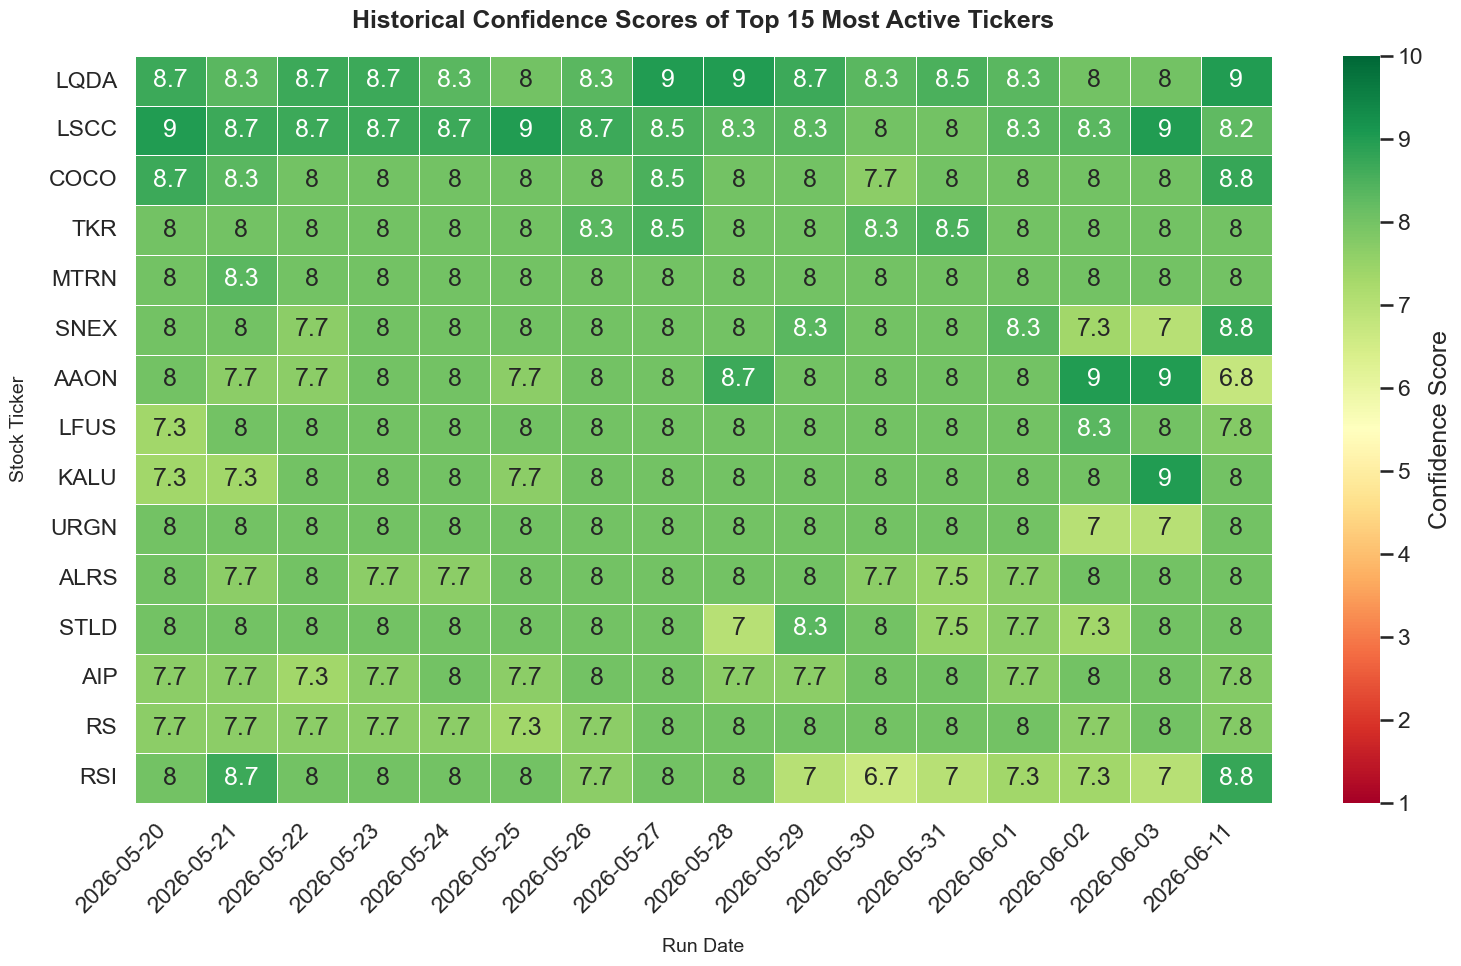

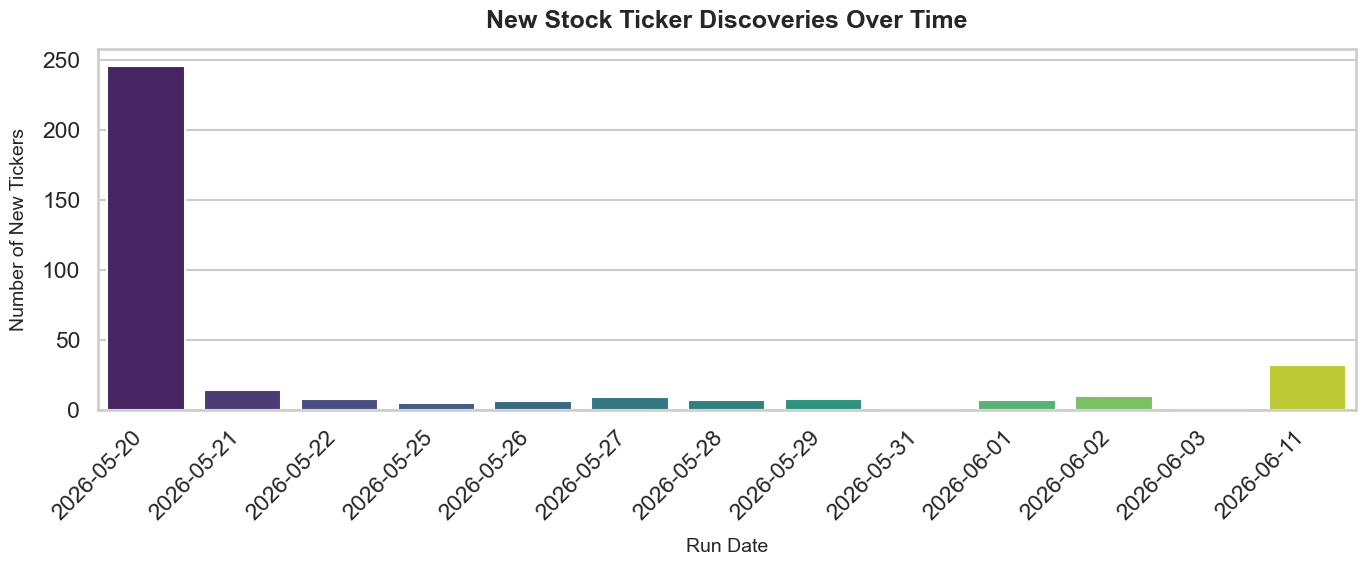

In [15]:
# 1. Seaborn Heatmap of Confidence Scores for Top Tickers
top_tickers = ticker_stats_sorted.head(15)["ticker"].tolist()
top_scores_pivot = scores_pivot.loc[top_tickers]

plt.figure(figsize=(16, 10))
sns.heatmap(
    top_scores_pivot,
    annot=True,
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={"label": "Confidence Score"},
    vmin=1,
    vmax=10
)
plt.title("Historical Confidence Scores of Top 15 Most Active Tickers", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Run Date", fontsize=14, labelpad=15)
plt.ylabel("Stock Ticker", fontsize=14, labelpad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. Seaborn Bar Plot of New Tickers Count
plt.figure(figsize=(14, 6))
sns.barplot(
    data=new_ticker_counts,
    x="run_date",
    y="new_ticker_count",
    palette="viridis",
    hue="run_date",
    legend=False
)
plt.title("New Stock Ticker Discoveries Over Time", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Run Date", fontsize=14, labelpad=10)
plt.ylabel("Number of New Tickers", fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
# 3. Plotly Interactive Score Trend Chart for Selected Tickers
df_plot = df_scores[df_scores["ticker"].isin(top_tickers)].sort_values(by="run_date")

fig = px.line(
    df_plot,
    x="run_date",
    y="confidence_score",
    color="ticker",
    markers=True,
    hover_data={
        "ticker": True,
        "run_date": True,
        "confidence_score": ":.1f",
        "suggested_entry_pivot": ":.2f",
        "suggested_stop_loss": ":.2f",
        "prompt_mode": True,
        "model": True
    },
    labels={
        "run_date": "Run Date",
        "confidence_score": "Confidence Score",
        "ticker": "Ticker Symbol"
    },
    title="Interactive Confidence Score Trajectories (Top 15 Most Active Stocks)"
)

fig.update_layout(
    title_font_size=20,
    hovermode="closest",
    xaxis_tickangle=-45,
    margin=dict(l=40, r=40, t=60, b=80),
    legend_title_text="Ticker"
)

fig.show()